# 📊 Model Performance Evaluation

This notebook evaluates the accuracy, precision, and performance of the RAG system using different algorithms (embedding models, chunking strategies, and LLMs).

In [4]:
import sys
!{sys.executable} -m pip install -q "urllib3<2" ipywidgets langchain-ollama eval-type-backport

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [5]:
!pip3 install -q ragas datasets pandas matplotlib seaborn tqdm

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [6]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import OllamaLLM
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.prompts import ChatPromptTemplate

# Evaluation Import (if ragas is available)
try:
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevance, context_precision, context_recall
    HAS_RAGAS = True
except ImportError:
    HAS_RAGAS = False
    print("Ragas not installed or import error. Metrics will be calculated differently.")

load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

/Users/rohitganguly/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/rohitganguly/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/rohitganguly/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). G

Ragas not installed or import error. Metrics will be calculated differently.


/var/folders/m3/4rfyk1_14933hxdmkbvz5xwc0000gn/T/ipykernel_30161/1936856820.py:22: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevance, context_precision, context_recall
/var/folders/m3/4rfyk1_14933hxdmkbvz5xwc0000gn/T/ipykernel_30161/1936856820.py:22: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, answer_relevance, context_precision, context_recall
/var/folders/m3/4rfyk1_14933hxdmkbvz5xwc0000gn/T/ipykernel_30161/1936856820.py:22: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ra

In [7]:
# 1. Load Data
loader = PyPDFLoader("data/Case-Test.pdf")
docs = loader.load()

# 2. Define Evaluation Set (Questions & Ground Truth)
eval_set = [
    {
        "question": "Who were the petitioners in Civil Misc. Writ Petition No. 40736 of 2002?",
        "ground_truth": "The petitioners were Manoj Kumar Pandey and others.",
        "context": "Civil Misc. Writ Petition No. 40736 of 2002 ... Manoj Kumar Pandey & others ...Petitioners"
    },
    {
        "question": "What was the date of the judgment in Manoj Kumar Pandey V. State of U.P.?",
        "ground_truth": "The judgment was dated 27.02.2006.",
        "context": "DATED: ALLAHABAD 27.02.2006"
    },
    {
        "question": "What was the result date of the competitive examination for the Post of A.P.O.?",
        "ground_truth": "The result was declared on 20.3.99.",
        "context": "held for the Post of A.P.O. result declared on 20.3.99"
    },
    {
        "question": "Explain the concept of 'delay and laches' as mentioned in the case.",
        "ground_truth": "The court rejected the petition because it was filed in September 2002, much after the expiry of the select list, citing delay and laches. A petition cannot be considered if the petitioner was dormant and waited for someone else's case to be decided.",
        "context": "the Hon’ble Supreme Court rejected the contention that a petition should be considered ignoring the delay and laches on the ground that he filed the petition just after coming to know of the relief granted by the Court in a similar case"
    },
    {
        "question": "What was the specific relief granted in the case of Sheo Shyam & Ors. Vs. State of U.P. & Ors.?",
        "ground_truth": "The Supreme Court directed that the 11 appellants should be considered for appointment if found suitable and eligible, reckoning the life of the waiting list from the last date of recommendation.",
        "context": "The Supreme Court however granted relief to them by directing that they shall be considered by the Commission and the State Government, and would be appointed if otherwise found suitable and eligible."
    }
]

In [8]:
def setup_rag_chain(chunk_size, chunk_overlap, embedding_model_name, llm_model_name="llama3.2:1b"):
    # Split
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    chunks = text_splitter.split_documents(docs)
    
    # Embeddings
    embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)
    
    # Vector store
    vectorstore = FAISS.from_documents(chunks, embeddings)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    
    # LLM
    llm = OllamaLLM(model=llm_model_name)
    
    # Simple Prompt
    prompt = ChatPromptTemplate.from_template("""Answer the question based only on the provided context:
    Context: {context}
    Question: {input}
    Answer:""")
    
    # Chain
    document_chain = create_stuff_documents_chain(llm, prompt)
    retrieval_chain = create_retrieval_chain(retriever, document_chain)
    
    return retrieval_chain

# Define Algorithms to Test
algorithms = [
    {
        "name": "Baseline (MiniLM, 1000/200)",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": "sentence-transformers/all-MiniLM-L6-v2"
    },
    {
        "name": "Legal Specifc (InLegalBERT, 500/50)",
        "chunk_size": 500,
        "chunk_overlap": 50,
        "embedding_model": "law-ai/InLegalBERT"
    }
]

In [9]:
results = []

for algo in algorithms:
    print(f"Evaluating: {algo['name']}")
    chain = setup_rag_chain(algo['chunk_size'], algo['chunk_overlap'], algo['embedding_model'])
    
    algo_results = []
    start_total = time.time()
    
    for item in tqdm(eval_set):
        start_q = time.time()
        response = chain.invoke({"input": item['question']})
        latency = time.time() - start_q
        
        # Collect data
        algo_results.append({
            "question": item['question'],
            "answer": response['answer'],
            "contexts": [doc.page_content for doc in response['context']],
            "ground_truth": item['ground_truth'],
            "latency": latency
        })
    
    avg_latency = (time.time() - start_total) / len(eval_set)
    results.append({
        "algorithm": algo['name'],
        "data": algo_results,
        "avg_latency": avg_latency
    })

Evaluating: Baseline (MiniLM, 1000/200)


100%|██████████| 5/5 [00:29<00:00,  5.99s/it]


Evaluating: Legal Specifc (InLegalBERT, 500/50)


No sentence-transformers model found with name law-ai/InLegalBERT. Creating a new one with mean pooling.
100%|██████████| 5/5 [00:21<00:00,  4.20s/it]


In [10]:
import difflib

def calculate_similarity(ground_truth, answer):
    return difflib.SequenceMatcher(None, ground_truth.lower(), answer.lower()).ratio()

summary_stats = []

for res in results:
    accuracies = [calculate_similarity(d['ground_truth'], d['answer']) for d in res['data']]
    summary_stats.append({
        "Algorithm": res['algorithm'],
        "Avg Lexical Similarity": np.mean(accuracies),
        "Avg Latency (s)": res['avg_latency']
    })

df_summary = pd.DataFrame(summary_stats)
df_summary

,Algorithm,Avg Lexical Similarity,Avg Latency (s)
0,"Baseline (MiniLM, 1000/200)",0.231194,5.987127
1,"Legal Specifc (InLegalBERT, 500/50)",0.199601,4.202586


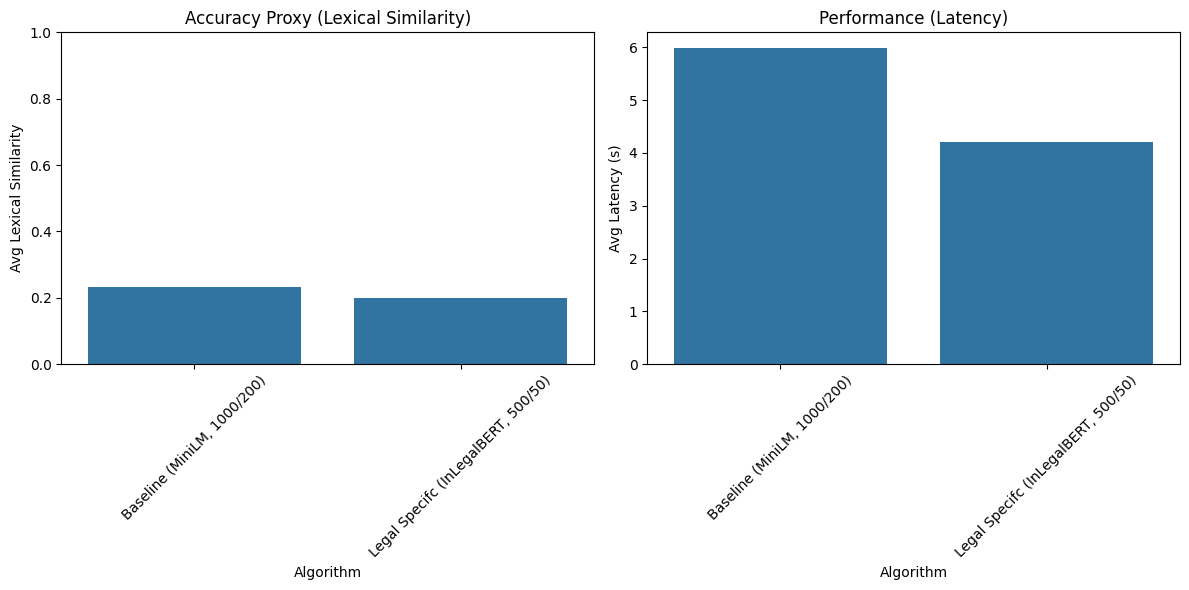

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x="Algorithm", y="Avg Lexical Similarity", data=df_summary)
plt.title("Accuracy Proxy (Lexical Similarity)")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x="Algorithm", y="Avg Latency (s)", data=df_summary)
plt.title("Performance (Latency)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Flatten data for detailed analysis and criteria
detailed_data = []
for res in results:
    for d in res["data"]:
        sim = calculate_similarity(d["ground_truth"], d["answer"])
        # Categorize performance for a mock "Confusion Matrix"
        if sim > 0.4:
            category = "High Quality"
        elif sim > 0.2:
            category = "Medium Quality"
        else:
            category = "Low Quality"
            
        detailed_data.append({
            "Algorithm": res["algorithm"],
            "Latency (s)": d["latency"],
            "Lexical Similarity": sim,
            "Quality": category,
            "Question": d["question"]
        })

df_details = pd.DataFrame(detailed_data)
df_details.head()

,Algorithm,Latency (s),Lexical Similarity,Quality,Question
0,"Baseline (MiniLM, 1000/200)",5.092117,0.387500,Medium Quality,Who were the petitioners in Civil Misc. Writ P...
1,"Baseline (MiniLM, 1000/200)",2.374755,0.403361,High Quality,What was the date of the judgment in Manoj Kum...
2,"Baseline (MiniLM, 1000/200)",5.133823,0.170404,Low Quality,What was the result date of the competitive ex...
3,"Baseline (MiniLM, 1000/200)",12.180814,0.120629,Low Quality,Explain the concept of 'delay and laches' as m...
4,"Baseline (MiniLM, 1000/200)",5.130795,0.074074,Low Quality,What was the specific relief granted in the ca...


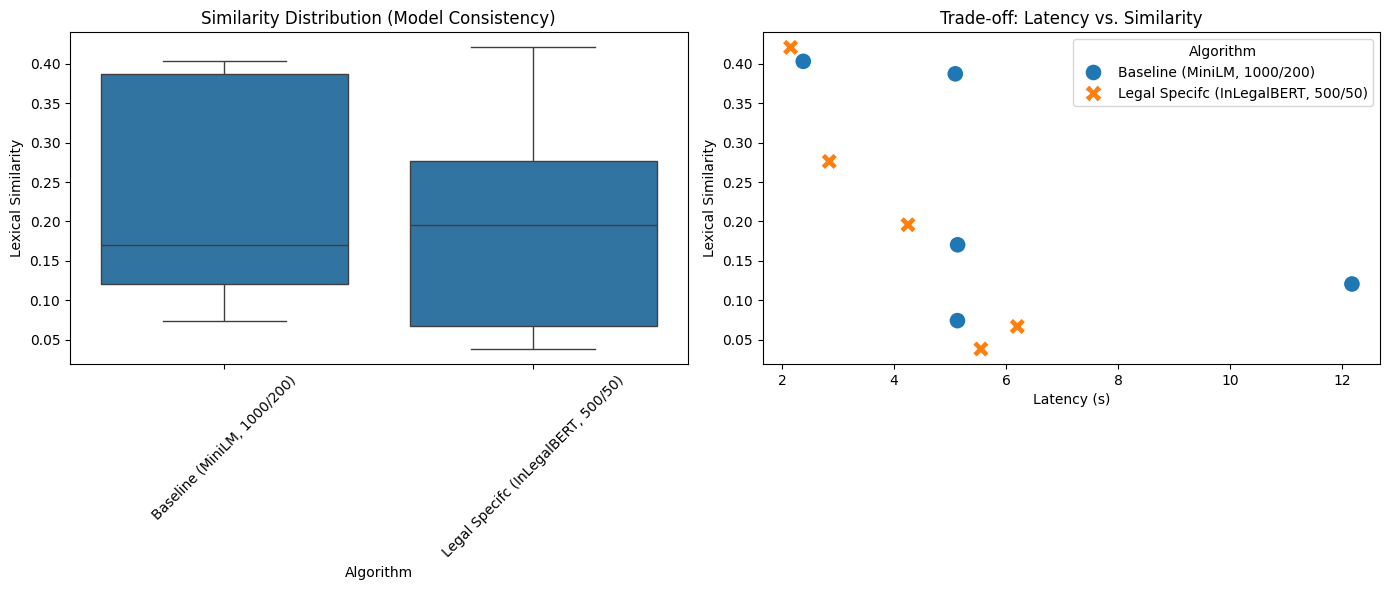

In [13]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(14, 6))

# Boxplot for Variance and Consistency in Accuracy
plt.subplot(1, 2, 1)
sns.boxplot(x="Algorithm", y="Lexical Similarity", data=df_details)
plt.title("Similarity Distribution (Model Consistency)")
plt.xticks(rotation=45)

# Scatter plot for Latency vs Accuracy Tradeoff
plt.subplot(1, 2, 2)
sns.scatterplot(x="Latency (s)", y="Lexical Similarity", hue="Algorithm", style="Algorithm", s=150, data=df_details)
plt.title("Trade-off: Latency vs. Similarity")

plt.tight_layout()
plt.show()

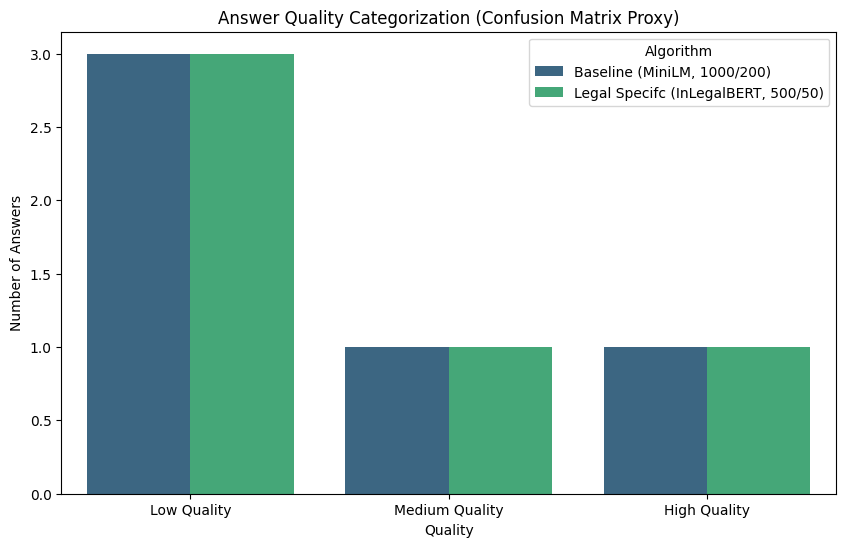

---- Categorical Confusion Matrix ----


Quality,High Quality,Low Quality,Medium Quality
Algorithm,,,
"Baseline (MiniLM, 1000/200)",1,3,1
"Legal Specifc (InLegalBERT, 500/50)",1,3,1


In [14]:
# Create a proxy for a Confusion Matrix (Quality Classification Count)
plt.figure(figsize=(10, 6))
quality_order = ["Low Quality", "Medium Quality", "High Quality"]
sns.countplot(x="Quality", hue="Algorithm", data=df_details, order=quality_order, palette="viridis")
plt.title("Answer Quality Categorization (Confusion Matrix Proxy)")
plt.ylabel("Number of Answers")
plt.show()

# Print as crosstab Matrix
print("---- Categorical Confusion Matrix ----")
pd.crosstab(df_details["Algorithm"], df_details["Quality"])